In [1]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np
from datetime import timedelta

In [2]:
full_dataset_df = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = full_dataset_df.copy()

In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [5]:
df_X["date"] = pd.to_datetime(df_X["time"]).dt.date

df_X = df_X.sort_values(["userId", "time"])

df_X_1 = df_X.groupby(["userId", "date"])["length"].sum().reset_index()

In [6]:
start_date = df_X_1["date"].min()
end_date = df_X_1["date"].max()

In [7]:
df_user_id_date = pd.DataFrame()

In [8]:
df_user_id_date["userId"] = df_X_1["userId"].unique()

In [9]:
df_merge_days = pd.DataFrame()

df_merge_days["date"] = np.arange(start_date, end_date + timedelta(days = 1), timedelta(days = 1))

In [10]:
df_merge_days["date"] = pd.to_datetime(df_merge_days["date"]).dt.date

In [11]:
df_user_id_days = df_user_id_date.merge(df_merge_days, how="cross")

In [12]:
df_user_id_days

,userId,date
0,1000035,2018-10-01
1,1000035,2018-10-02
2,1000035,2018-10-03
3,1000035,2018-10-04
4,1000035,2018-10-05
...,...,...
555583,1999905,2018-11-01
555584,1999905,2018-11-02
555585,1999905,2018-11-03
555586,1999905,2018-11-04


In [13]:
df_X_1_merge = df_X_1.merge(df_user_id_days, on = ["userId", "date"], how="right")

In [14]:
df_X_1_merge = df_X_1_merge.drop_duplicates()

In [15]:
df_X_1_merge

,userId,date,length
0,1000035,2018-10-01,NaN
1,1000035,2018-10-02,NaN
2,1000035,2018-10-03,NaN
3,1000035,2018-10-04,NaN
4,1000035,2018-10-05,625.63129
...,...,...,...
555583,1999905,2018-11-01,NaN
555584,1999905,2018-11-02,NaN
555585,1999905,2018-11-03,NaN
555586,1999905,2018-11-04,NaN


In [16]:
df_X_1_merge["length"] = df_X_1_merge["length"].fillna(0.0)

In [17]:
df_X_1_merge

,userId,date,length
0,1000035,2018-10-01,0.00000
1,1000035,2018-10-02,0.00000
2,1000035,2018-10-03,0.00000
3,1000035,2018-10-04,0.00000
4,1000035,2018-10-05,625.63129
...,...,...,...
555583,1999905,2018-11-01,0.00000
555584,1999905,2018-11-02,0.00000
555585,1999905,2018-11-03,0.00000
555586,1999905,2018-11-04,0.00000


In [18]:
df_X_1_merge = df_X_1_merge.sort_values(["userId", "date"], ascending=True)

In [19]:
df_X_1_merge["rolling_avg"] = df_X_1_merge.groupby(["userId"])["length"].\
    transform(lambda s: s.rolling(window = 3).mean())

In [20]:
df_X_1_merge

,userId,date,length,rolling_avg
0,1000035,2018-10-01,0.00000,NaN
1,1000035,2018-10-02,0.00000,NaN
2,1000035,2018-10-03,0.00000,0.000000
3,1000035,2018-10-04,0.00000,0.000000
4,1000035,2018-10-05,625.63129,208.543763
...,...,...,...,...
555583,1999905,2018-11-01,0.00000,3365.784263
555584,1999905,2018-11-02,0.00000,3365.784263
555585,1999905,2018-11-03,0.00000,0.000000
555586,1999905,2018-11-04,0.00000,0.000000


In [21]:
#df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg"])]["rolling_avg"] = df_X_1_merge.groupby(["userId"])

df_temp = df_X_1_merge[~pd.isna(df_X_1_merge["rolling_avg"])].groupby(["userId"])["date"].min()

df_first_rolling_avg = df_X_1_merge.merge(df_temp, on=["userId", "date"])

In [22]:
df_first_rolling_avg_dropped = df_first_rolling_avg[["userId", "rolling_avg"]]

In [23]:
df_first_rolling_avg

,userId,date,length,rolling_avg
0,1000035,2018-10-03,0.00000,0.000000
1,1000103,2018-10-03,0.00000,0.000000
2,1000164,2018-10-03,0.00000,75.807197
3,1000168,2018-10-03,0.00000,0.000000
4,1000182,2018-10-03,0.00000,0.000000
...,...,...,...,...
15428,1999241,2018-10-03,0.00000,2571.976507
15429,1999382,2018-10-03,8425.23283,2808.410943
15430,1999781,2018-10-03,17616.84204,26968.409443
15431,1999848,2018-10-03,0.00000,3492.434467


In [24]:
df_first_rolling_avg_dropped

,userId,rolling_avg
0,1000035,0.000000
1,1000103,0.000000
2,1000164,75.807197
3,1000168,0.000000
4,1000182,0.000000
...,...,...
15428,1999241,2571.976507
15429,1999382,2808.410943
15430,1999781,26968.409443
15431,1999848,3492.434467


In [25]:
df_X_1_merge = df_X_1_merge.merge(df_first_rolling_avg_dropped, on = "userId")

In [26]:

mask = df_X_1_merge["rolling_avg_x"].isna()
df_X_1_merge.loc[mask, "rolling_avg_x"] = df_X_1_merge.loc[mask, "rolling_avg_y"]


#df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg_x"])]["rolling_avg_x"] = df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg_x"])]["rolling_avg_y"]

In [27]:
df_X_1_merge = df_X_1_merge[["userId", "date", "length", "rolling_avg_x"]]

In [28]:
df_X_1_merge = df_X_1_merge.rename(columns={"rolling_avg_x" : "rolling_avg"})

In [29]:
df_X_1_merge

,userId,date,length,rolling_avg
0,1000035,2018-10-01,0.00000,0.000000
1,1000035,2018-10-02,0.00000,0.000000
2,1000035,2018-10-03,0.00000,0.000000
3,1000035,2018-10-04,0.00000,0.000000
4,1000035,2018-10-05,625.63129,208.543763
...,...,...,...,...
555583,1999905,2018-11-01,0.00000,3365.784263
555584,1999905,2018-11-02,0.00000,3365.784263
555585,1999905,2018-11-03,0.00000,0.000000
555586,1999905,2018-11-04,0.00000,0.000000


In [30]:
#df_X_1_merge["abs_usage_change_7_days"] = df_X_1_merge.groupby("userId")["rolling_avg"].diff(7)

In [31]:
#df_X_1_merge["week_number"] = df_X_1_merge["date"].dt.isocalendar().week

df_X_1_merge["date"] = pd.to_datetime(df_X_1_merge["date"])

In [32]:
df_X_1_merge["week_number"] = df_X_1_merge["date"].dt.isocalendar().week

In [33]:
df_X_1_merge

,userId,date,length,rolling_avg,week_number
0,1000035,2018-10-01,0.00000,0.000000,40
1,1000035,2018-10-02,0.00000,0.000000,40
2,1000035,2018-10-03,0.00000,0.000000,40
3,1000035,2018-10-04,0.00000,0.000000,40
4,1000035,2018-10-05,625.63129,208.543763,40
...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,3365.784263,44
555584,1999905,2018-11-02,0.00000,3365.784263,44
555585,1999905,2018-11-03,0.00000,0.000000,44
555586,1999905,2018-11-04,0.00000,0.000000,44


In [34]:
df_X_1_merge["weekly_average"] = df_X_1_merge.groupby(["userId", "week_number"])["rolling_avg"].transform("mean")

In [35]:
df_X_1_merge

,userId,date,length,rolling_avg,week_number,weekly_average
0,1000035,2018-10-01,0.00000,0.000000,40,89.375899
1,1000035,2018-10-02,0.00000,0.000000,40,89.375899
2,1000035,2018-10-03,0.00000,0.000000,40,89.375899
3,1000035,2018-10-04,0.00000,0.000000,40,89.375899
4,1000035,2018-10-05,625.63129,208.543763,40,89.375899
...,...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,3365.784263,44,1442.478970
555584,1999905,2018-11-02,0.00000,3365.784263,44,1442.478970
555585,1999905,2018-11-03,0.00000,0.000000,44,1442.478970
555586,1999905,2018-11-04,0.00000,0.000000,44,1442.478970


In [36]:
df_weekly_avg_time = df_X_1_merge[["userId", "week_number", "weekly_average"]].drop_duplicates()

In [37]:
df_weekly_avg_time = df_weekly_avg_time.sort_values(["userId", "week_number"], ascending=False)

In [38]:
df_a = df_weekly_avg_time.merge(df_y, on = "userId")

In [39]:
df_a

,userId,week_number,weekly_average,Cancellation Confirmation
0,1999905,45,0.000000,0
1,1999905,44,1442.478970,0
2,1999905,43,2909.670900,0
3,1999905,42,516.897672,0
4,1999905,41,2960.041207,0
...,...,...,...,...
92593,1000035,44,5617.670786,0
92594,1000035,43,7968.669578,0
92595,1000035,42,10159.690515,0
92596,1000035,41,2302.212129,0


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='week_number', ylabel='weekly_average'>

/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


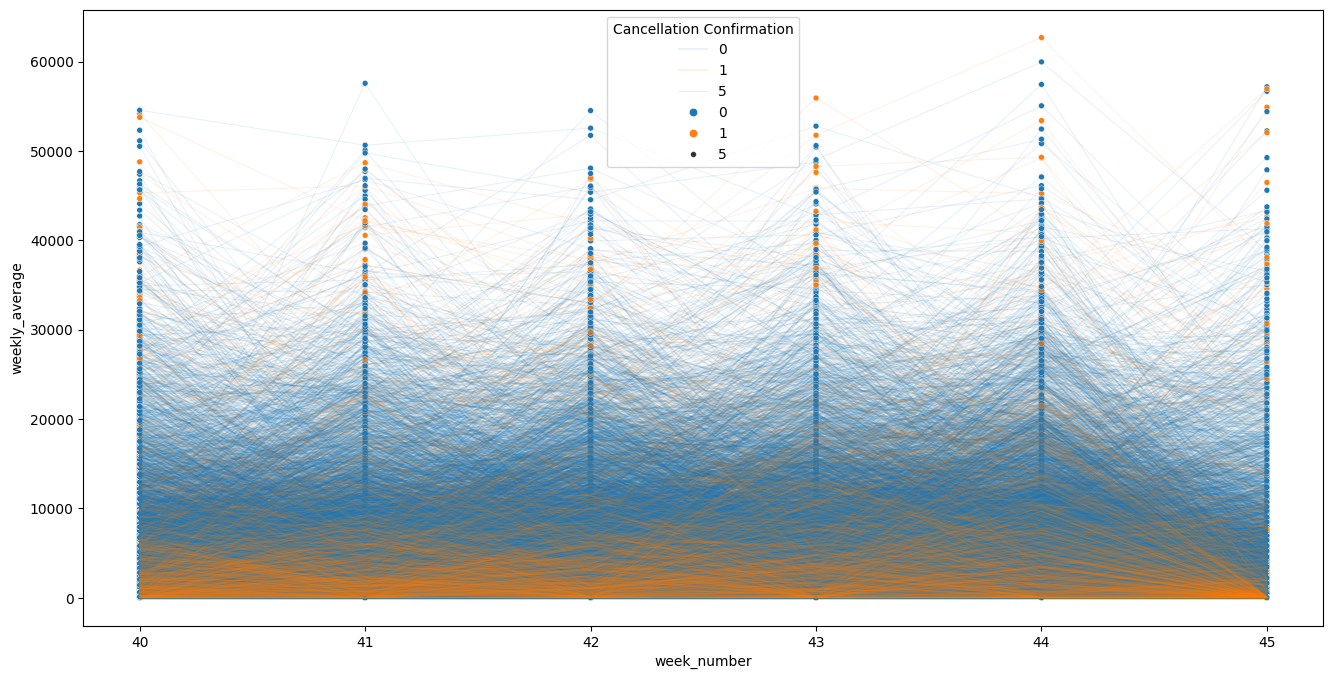

In [41]:
plt.figure(figsize=(16,8))
sns.lineplot(df_a, x = "week_number", y = "weekly_average", units="userId", estimator = None, hue="Cancellation Confirmation", size=5, alpha = 0.1)
sns.scatterplot(df_a, x = "week_number", y = "weekly_average", hue="Cancellation Confirmation", size=5)

<Axes: xlabel='week_number', ylabel='weekly_average'>

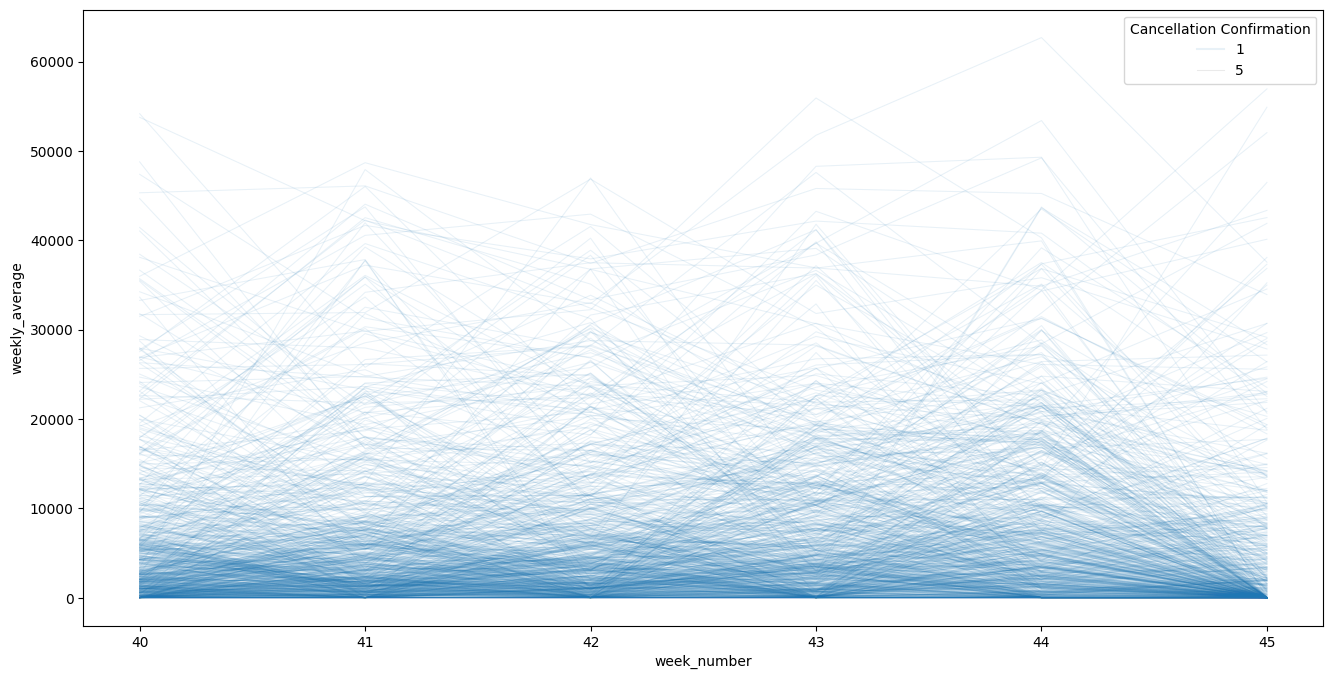

In [42]:
plt.figure(figsize=(16,8))
sns.lineplot(df_a[df_a["Cancellation Confirmation"] == 1], x = "week_number", y = "weekly_average", units="userId", estimator = None, hue="Cancellation Confirmation", size=5, alpha = 0.1)
#sns.scatterplot(df_a, x = "week_number", y = "weekly_average", hue="Cancellation Confirmation", size=5)

<Axes: xlabel='week_number', ylabel='weekly_average'>

/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


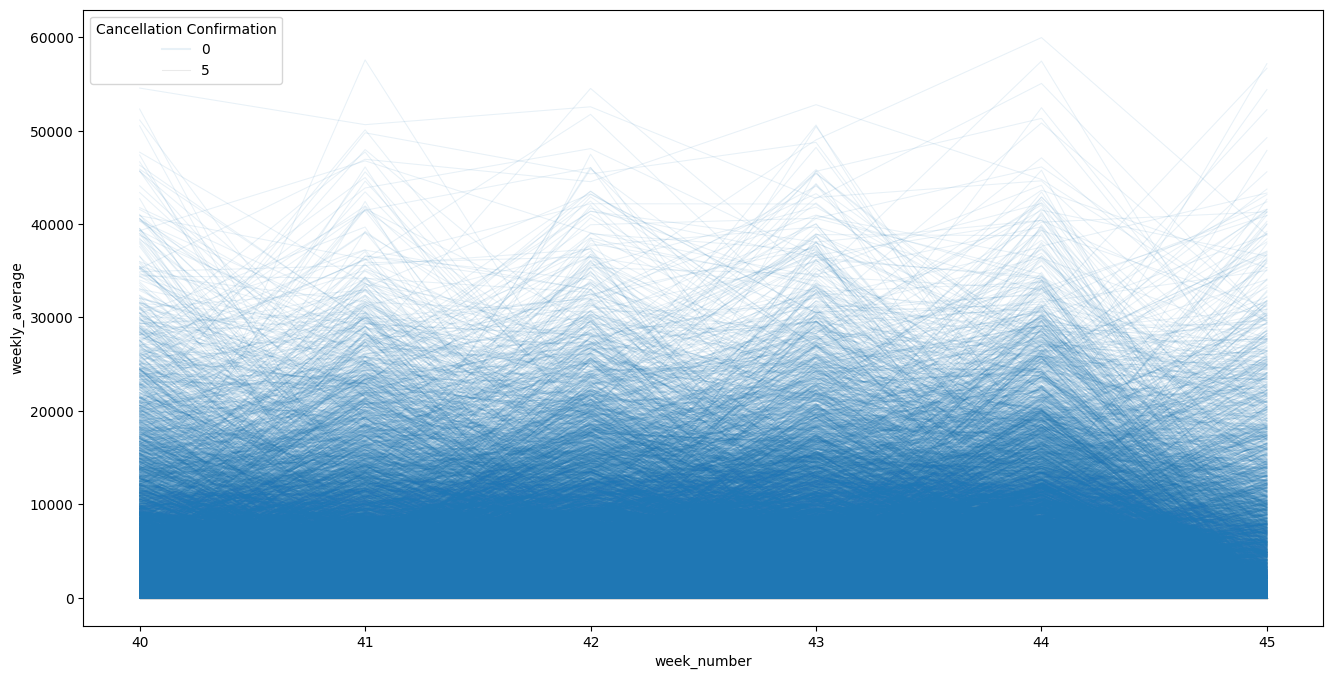

In [43]:
plt.figure(figsize=(16,8))
sns.lineplot(df_a[df_a["Cancellation Confirmation"] == 0], x = "week_number", y = "weekly_average", units="userId", estimator = None, hue="Cancellation Confirmation", size=5, alpha = 0.1)
#sns.scatterplot(df_a, x = "week_number", y = "weekly_average", hue="Cancellation Confirmation", size=5)

<Axes: xlabel='week_number', ylabel='weekly_average'>

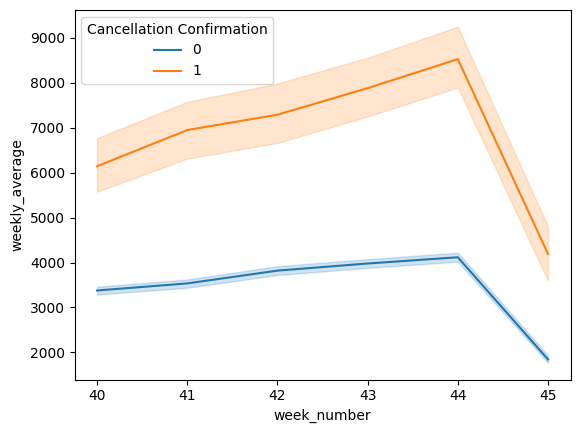

In [44]:
sns.lineplot(df_a, x = "week_number", y = "weekly_average", hue = "Cancellation Confirmation")

<Axes: xlabel='Cancellation Confirmation', ylabel='weekly_average'>

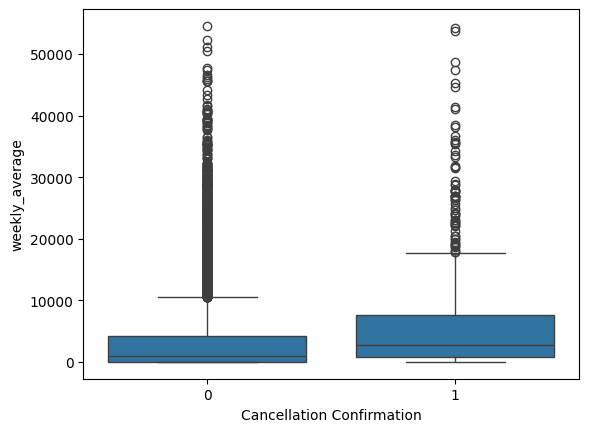

In [45]:
sns.boxplot(df_a[df_a["week_number"]==40], x = "Cancellation Confirmation", y = "weekly_average")

<Axes: xlabel='Cancellation Confirmation', ylabel='weekly_average'>

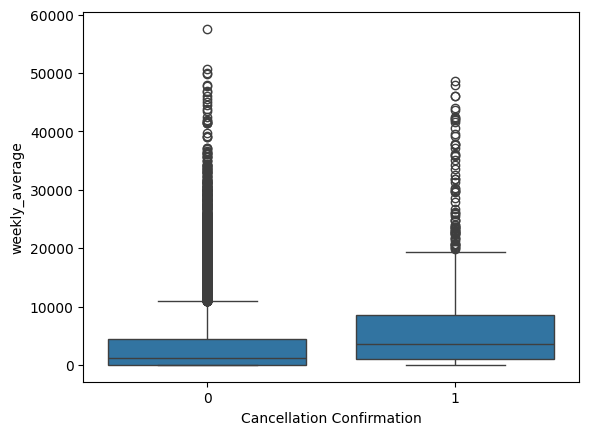

In [46]:
sns.boxplot(df_a[df_a["week_number"]==41], x = "Cancellation Confirmation", y = "weekly_average")

<Axes: xlabel='Cancellation Confirmation', ylabel='weekly_average'>

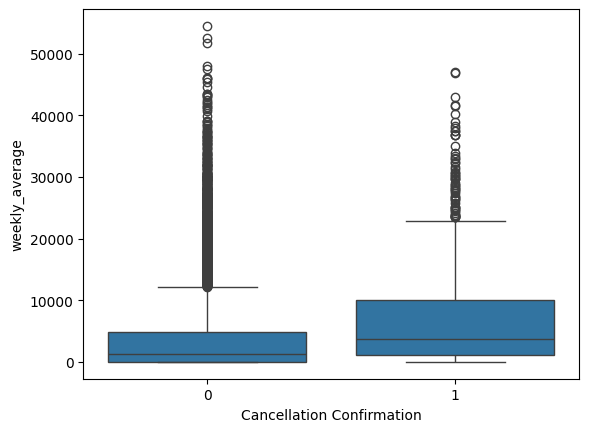

In [47]:
sns.boxplot(df_a[df_a["week_number"]==42], x = "Cancellation Confirmation", y = "weekly_average")

<Axes: xlabel='Cancellation Confirmation', ylabel='weekly_average'>

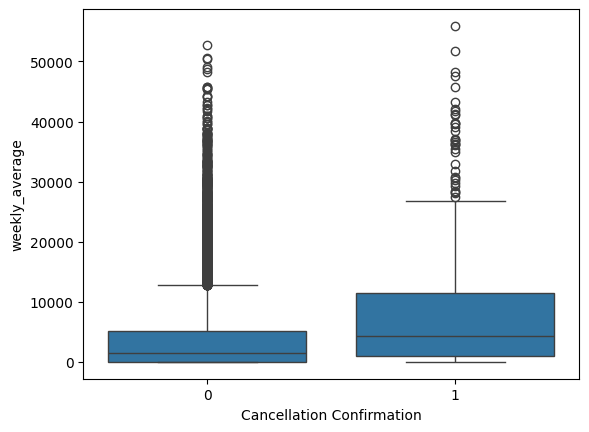

In [48]:
sns.boxplot(df_a[df_a["week_number"]==43], x = "Cancellation Confirmation", y = "weekly_average")